# Week 4 — Math Intuition for ML + Mini Project
**AI/ML Internship Program — Month 1: Foundations**

This notebook covers:
1. Intuitive math for ML — vectors, matrices, dot products, probability, gradients
2. A hands-on gradient descent demo
3. **Mini Project:** Full EDA on a new, independent dataset — the Palmer Penguins dataset

## 1. Vectors, Matrices, and Dot Products

- A **vector** is just a list of numbers — e.g. a data point with 3 features is a vector in 3D space.
- A **matrix** is a table of numbers — a full dataset (rows = samples, columns = features) is a matrix.
- The **dot product** measures how much two vectors "point in the same direction." In ML, it's the core operation behind predictions: `prediction = weights · features`.
- **Matrix multiplication** is just doing many dot products at once — this is how a whole dataset gets multiplied by a whole set of weights in one shot.

In [1]:
import numpy as np

# A single data point (feature vector): [study_hours, sleep_hours, attendance_pct]
x = np.array([5, 7, 90])

# Weights the model has "learned" for each feature
w = np.array([0.6, 0.3, 0.05])

# Dot product = weighted sum = the model's raw prediction
prediction = np.dot(x, w)
print("Feature vector:", x)
print("Weights:", w)
print("Dot product (prediction):", prediction)

Feature vector: [ 5  7 90]
Weights: [0.6  0.3  0.05]
Dot product (prediction): 9.6


In [2]:
# Matrix multiplication = many dot products at once
# 4 students (rows), 3 features each (columns)
X = np.array([
    [5, 7, 90],
    [2, 5, 60],
    [8, 6, 95],
    [4, 4, 70]
])

predictions = X @ w   # '@' is matrix multiplication in numpy
print("Dataset (4 students x 3 features):\n", X)
print("\nPredictions for all 4 students at once:", predictions)

Dataset (4 students x 3 features):
 [[ 5  7 90]
 [ 2  5 60]
 [ 8  6 95]
 [ 4  4 70]]

Predictions for all 4 students at once: [ 9.6   5.7  11.35  7.1 ]


## 2. Probability Basics

- **Probability** = how likely something is, between 0 and 1.
- **Conditional probability** `P(A | B)` = probability of A, *given that we already know B happened*.
- A **distribution** describes how likely each possible value is. The Normal (bell curve) distribution shows up constantly in ML.

In [3]:
import numpy as np
rng = np.random.default_rng(42)

# Simulate 1000 students' exam scores, normally distributed
scores = rng.normal(loc=70, scale=10, size=1000)

print(f"Mean score: {scores.mean():.2f}")
print(f"Std dev: {scores.std():.2f}")

# P(score > 85) -- an example of using a distribution to estimate probability
p_above_85 = (scores > 85).mean()
print(f"P(score > 85) ≈ {p_above_85:.3f}")

Mean score: 69.71
Std dev: 9.89
P(score > 85) ≈ 0.062


## 3. Derivatives, Gradients & Gradient Descent

- A **derivative** tells you the slope of a function at a point.
- A **gradient** generalizes this to multiple variables — it points toward steepest increase.
- **Gradient descent** = take small steps *opposite* the gradient to find the minimum. This is how models "learn."

Below: gradient descent finds the minimum of `f(x) = (x - 3)^2`, whose true minimum is `x = 3`.

Final x after gradient descent: 2.9889  (true minimum is 3)


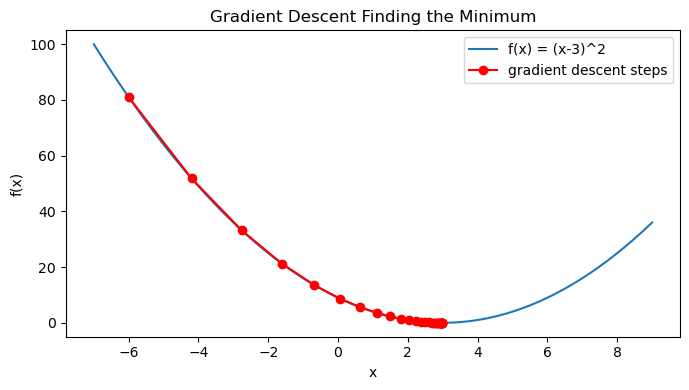

In [4]:
import matplotlib.pyplot as plt

def f(x):
    return (x - 3) ** 2

def gradient(x):
    return 2 * (x - 3)

x = -6.0
learning_rate = 0.1
history = [x]

for step in range(30):
    x = x - learning_rate * gradient(x)
    history.append(x)

print(f"Final x after gradient descent: {history[-1]:.4f}  (true minimum is 3)")

xs = np.linspace(-7, 9, 200)
plt.figure(figsize=(7, 4))
plt.plot(xs, f(xs), label="f(x) = (x-3)^2")
plt.plot(history, [f(v) for v in history], 'o-', color='red', label="gradient descent steps")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent Finding the Minimum")
plt.legend()
plt.tight_layout()
plt.show()

> **In one sentence:** training a model is gradient descent applied to a much more complicated function — instead of one variable `x`, there are thousands/millions of weights, and instead of `(x-3)^2`, the function is "how wrong are my predictions."

---
# Mini Project: EDA on a New Dataset — Palmer Penguins

Fresh, independent dataset (not used in Week 2 or Week 3), done end-to-end: load → clean → explore → visualize → summarize.

In [5]:
import pandas as pd

df = pd.read_csv("data/penguins.csv")
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Cleaning: check and handle missing values

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

df_clean = df.dropna().reset_index(drop=True)
print(f"\nRows before cleaning: {len(df)}, after cleaning: {len(df_clean)}")

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows before cleaning: 344, after cleaning: 333


### Exploratory Data Analysis

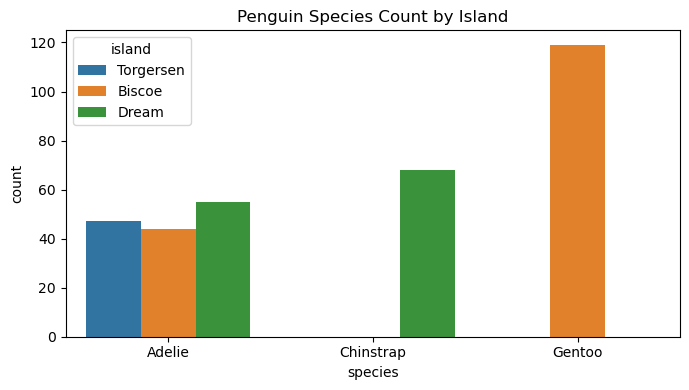

In [9]:
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="species", hue="island")
plt.title("Penguin Species Count by Island")
plt.tight_layout()
plt.show()

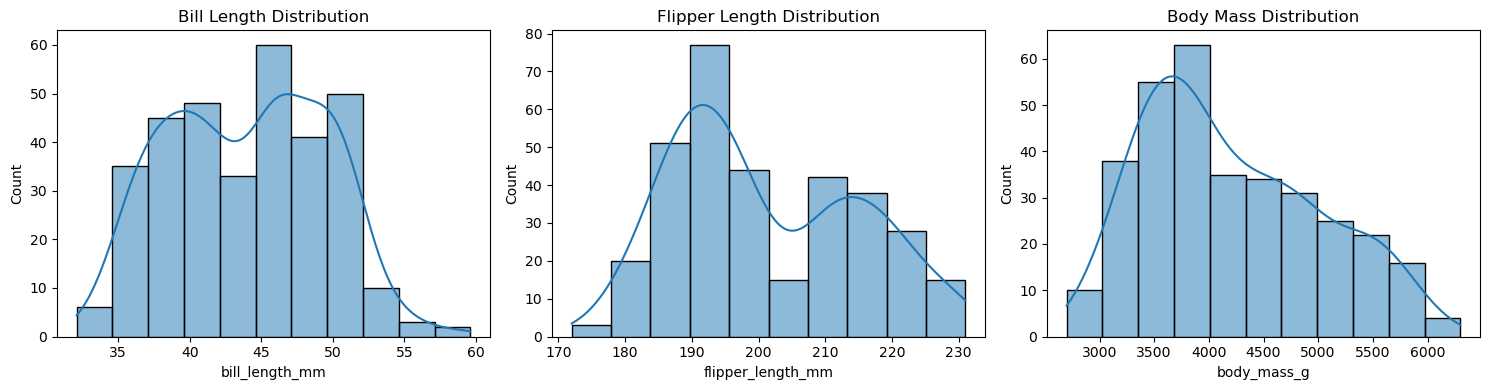

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_clean["bill_length_mm"], kde=True, ax=axes[0])
axes[0].set_title("Bill Length Distribution")

sns.histplot(df_clean["flipper_length_mm"], kde=True, ax=axes[1])
axes[1].set_title("Flipper Length Distribution")

sns.histplot(df_clean["body_mass_g"], kde=True, ax=axes[2])
axes[2].set_title("Body Mass Distribution")

plt.tight_layout()
plt.show()


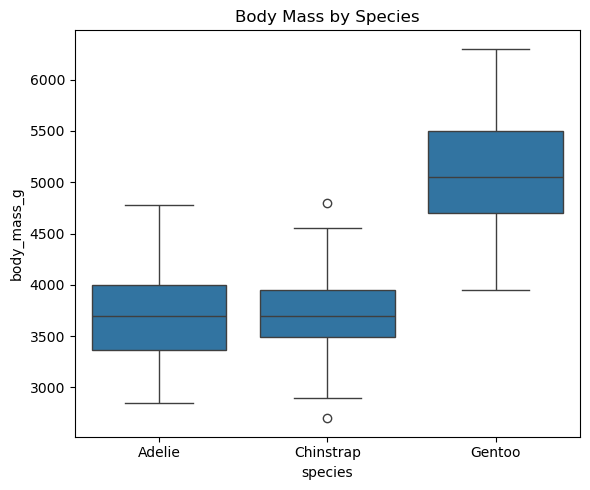

In [11]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_clean, x="species", y="body_mass_g")
plt.title("Body Mass by Species")
plt.tight_layout()
plt.show()
